## **Exploratory Data Analysis (EDA)**

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
# Load Data

df = pd.read_csv("..\data\processed\MAYBANK_preprocessed.csv", parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\lunwe\AppData\Local\Temp\ipykernel_31368\1823944016.py:3: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("..\data\processed\MAYBANK_preprocessed.csv", parse_dates=['Date'])


,Open,High,Low,Close,Volume,Return,MA5,MA10,Volatility,Target
Date,,,,,,,,,,
2015-09-14,4.507596,4.560941,4.486259,4.539603,22631700,0.011891,4.552405,4.538536,0.015938,1
2015-09-15,4.560940,4.651626,4.560940,4.571609,18416800,0.007050,4.551338,4.527867,0.011691,1
2015-09-17,4.614283,4.651625,4.566274,4.608949,28439300,0.008168,4.553472,4.539602,0.012150,1
2015-09-18,4.619620,4.646292,4.603616,4.640957,12595900,0.006945,4.569475,4.551872,0.011310,0
2015-09-21,4.614284,4.614284,4.480923,4.486258,19818000,-0.033333,4.569475,4.554005,0.018822,1


### Data Describe

In [3]:
df.tail(5)

,Open,High,Low,Close,Volume,Return,MA5,MA10,Volatility,Target
Date,,,,,,,,,,
2025-08-25,9.85,9.90,9.83,9.85,17724500,0.005102,9.806,9.802,0.002661,0
2025-08-26,9.85,9.88,9.75,9.75,81816700,-0.010152,9.796,9.806,0.005752,1
2025-08-27,9.78,9.83,9.72,9.79,7930800,0.004103,9.794,9.799,0.006207,1
2025-08-28,9.83,9.98,9.83,9.95,11065300,0.016343,9.828,9.810,0.009439,0
2025-08-29,9.95,9.95,9.86,9.91,975600,-0.004020,9.850,9.821,0.010041,0


In [4]:
# Data Basic Info

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2453 entries, 2015-09-14 to 2025-08-29
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Open        2453 non-null   float64
 1   High        2453 non-null   float64
 2   Low         2453 non-null   float64
 3   Close       2453 non-null   float64
 4   Volume      2453 non-null   int64  
 5   Return      2453 non-null   float64
 6   MA5         2453 non-null   float64
 7   MA10        2453 non-null   float64
 8   Volatility  2453 non-null   float64
 9   Target      2453 non-null   int64  
dtypes: float64(8), int64(2)
memory usage: 210.8 KB
None
              Open         High          Low        Close        Volume  \
count  2453.000000  2453.000000  2453.000000  2453.000000  2.453000e+03   
mean      6.683137     6.718639     6.648606     6.683728  9.693438e+06   
std       1.622418     1.628097     1.616316     1.621909  7.347086e+06   
min       4.389324     4.4

In [5]:
# Count the number of 0s and 1s
target_counts = df['Target'].value_counts()

print("Target class count:")
print(target_counts)

# If you want them separately:
num_ones = target_counts.get(1, 0)
num_zeros = target_counts.get(0, 0)

print(f"\nNumber of 1s: {num_ones}")
print(f"Number of 0s: {num_zeros}")

Target class count:
Target
0    1355
1    1098
Name: count, dtype: int64

Number of 1s: 1098
Number of 0s: 1355


In [6]:
print("\nTarget class proportions:")
print(target_counts / len(df))


Target class proportions:
Target
0    0.552385
1    0.447615
Name: count, dtype: float64


#### Intepretation: 
The dataset contains 2,453 daily stock trading records (2015–2025) with key features like price (Open, High, Low, Close), volume, returns, moving averages (MA5, MA10), and volatility. Prices range from ~4.37 to 10.42, average return is near zero, and the target variable (up/down) is moderately balanced (≈45% ups, 55% downs).

### Trend Plot

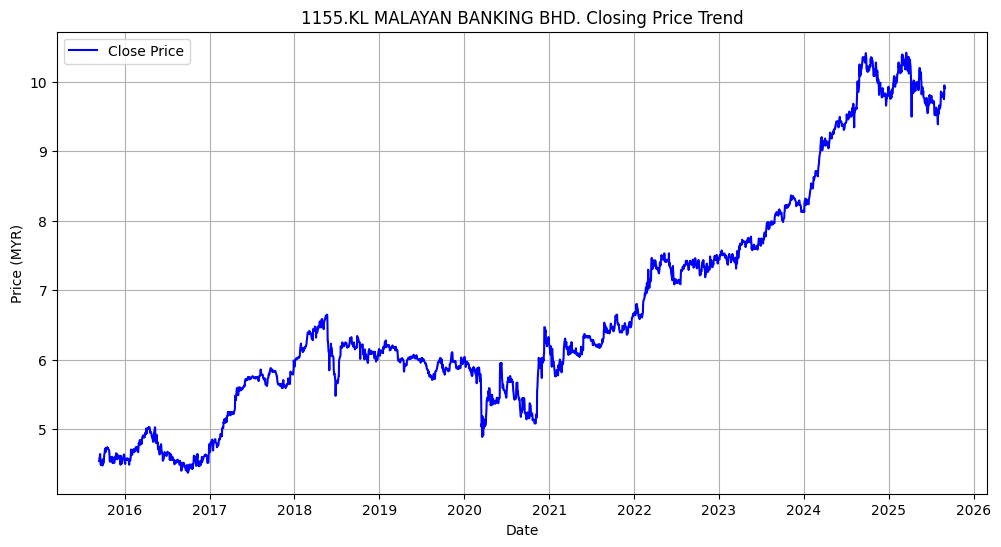

In [7]:
# Closing Price Trend

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.title('1155.KL MALAYAN BANKING BHD. Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Price (MYR)')
plt.legend()
plt.grid()
plt.show()

The closing price of 1155.KL shows a long-term upward trend from 2015 to 2025, with **notable growth acceleration from 2022 onwards**. Short-term fluctuations and minor corrections are present, but the overall price has nearly doubled in this period, reflecting a strong bullish performance.

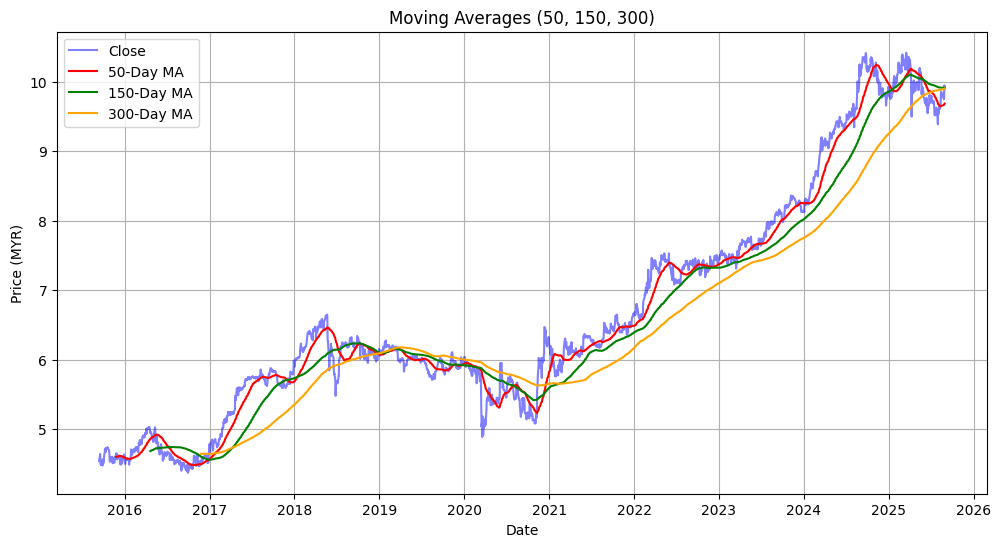

In [8]:
# Moving Average

df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA150'] = df['Close'].rolling(window=150).mean()
df['MA300'] = df['Close'].rolling(window=300).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close', color='blue', alpha=0.5)
plt.plot(df['MA50'], label='50-Day MA', color='red', linestyle='-')
plt.plot(df['MA150'], label='150-Day MA', color='green', linestyle='-')
plt.plot(df['MA300'], label='300-Day MA', color='orange', linestyle='-')
plt.title('Moving Averages (50, 150, 300)')
plt.xlabel('Date')
plt.ylabel('Price (MYR)')
plt.legend()
plt.grid()
plt.show()

The 50-day moving average (red) closely tracks short-term fluctuations, while the 150-day (green) and 300-day (orange) moving averages smooth out long-term trends. Crossovers between the shorter and longer moving averages signal potential trend reversals, with sustained upward momentum visible after 2022.

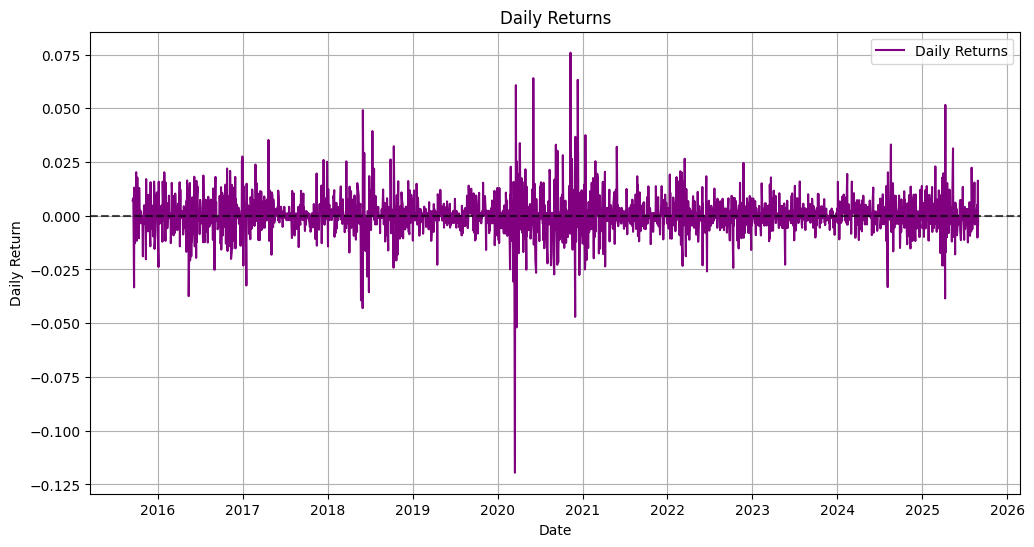

In [9]:
# Daily Returns

df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(12,6))
plt.plot(df['Daily_Return'], label='Daily Returns', color='purple')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid()
plt.show()

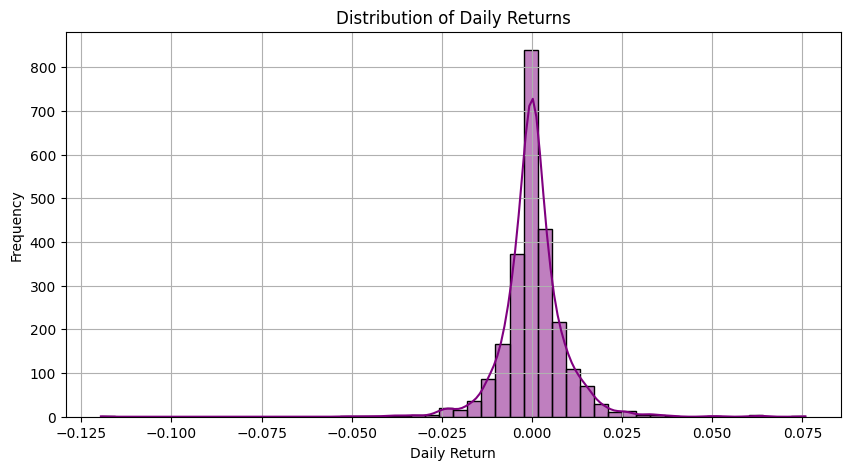

In [10]:
# --- 7. Histogram of Daily Returns ---
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid()
plt.show()

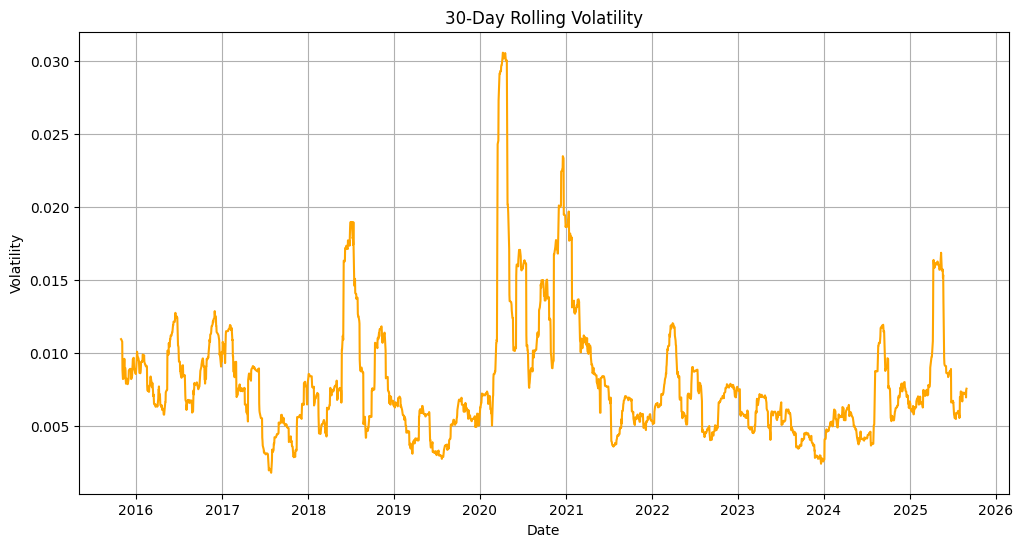

In [11]:
# --- 8. Rolling Volatility ---
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()
plt.figure(figsize=(12,6))
plt.plot(df['Volatility_30d'], color='orange')
plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.grid()
plt.show()

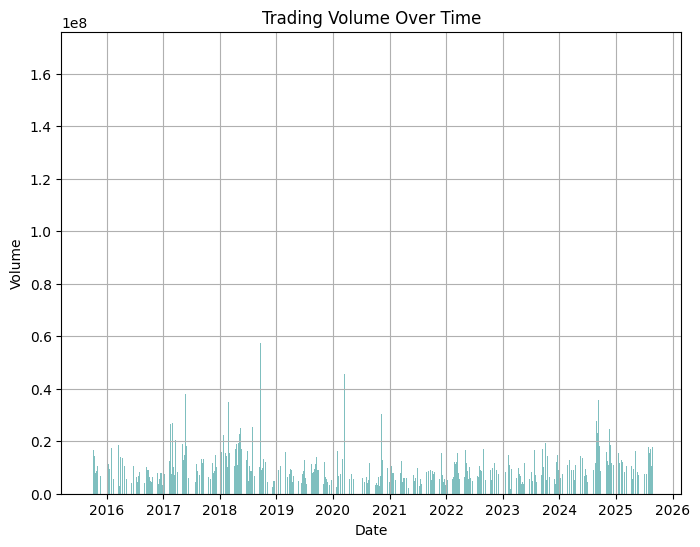

In [12]:
# --- 9. Trading Volume ---
if 'Volume' in df.columns:
    plt.figure(figsize=(8,6))
    plt.bar(df.index, df['Volume'], color='teal', alpha=0.5)
    plt.title('Trading Volume Over Time')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.grid()
    plt.show()

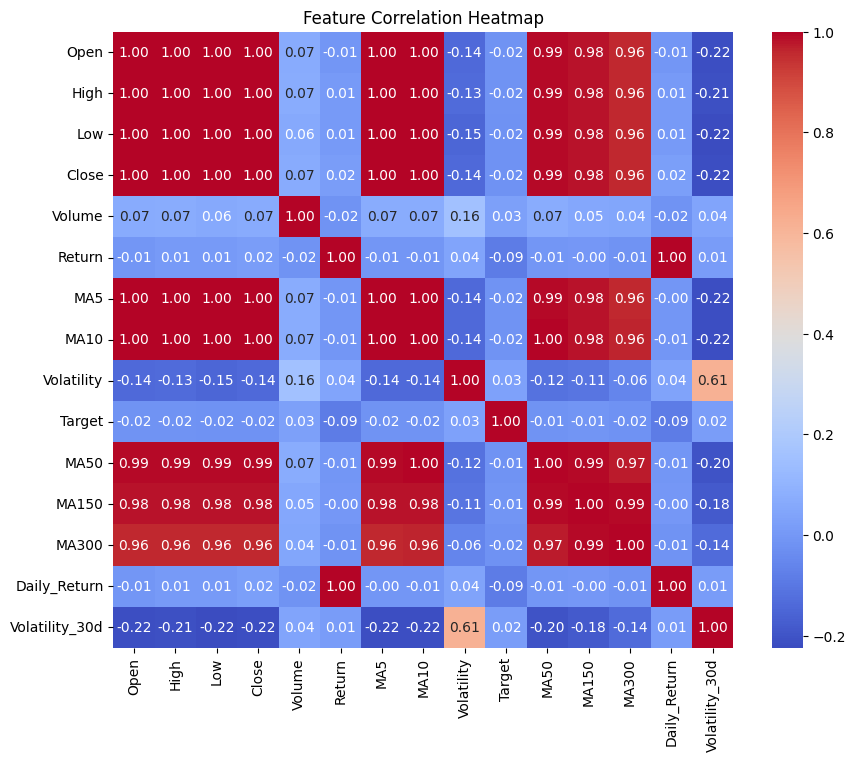

In [13]:
# --- 10. Correlation Heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

C:\Users\lunwe\AppData\Local\Temp\ipykernel_31368\2780685625.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = df['Daily_Return'].resample('M').mean()


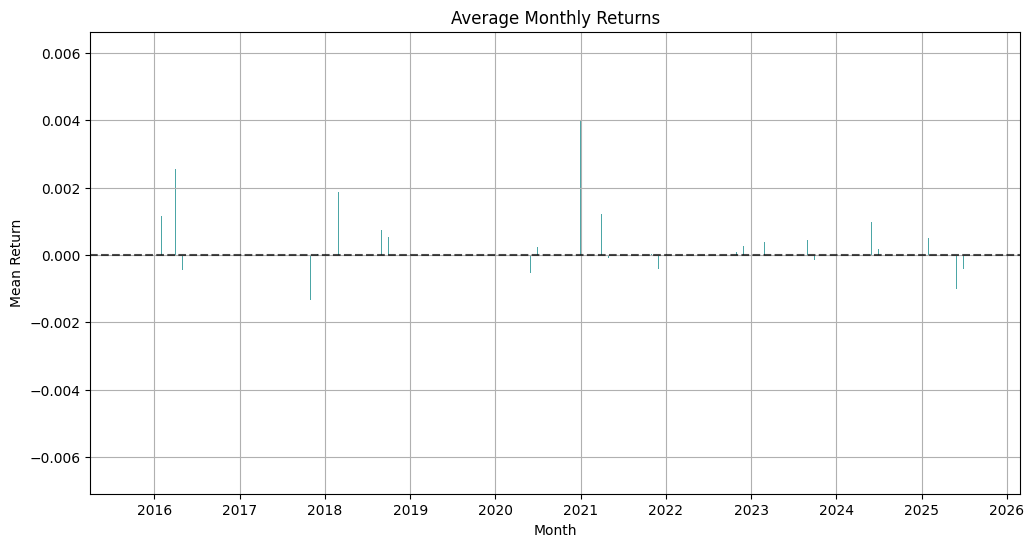

In [14]:
# --- 11. Monthly Returns ---
monthly_returns = df['Daily_Return'].resample('M').mean()
plt.figure(figsize=(12,6))
plt.bar(monthly_returns.index, monthly_returns, color='teal', alpha=0.7)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Average Monthly Returns')
plt.xlabel('Month')
plt.ylabel('Mean Return')
plt.grid()
plt.show()

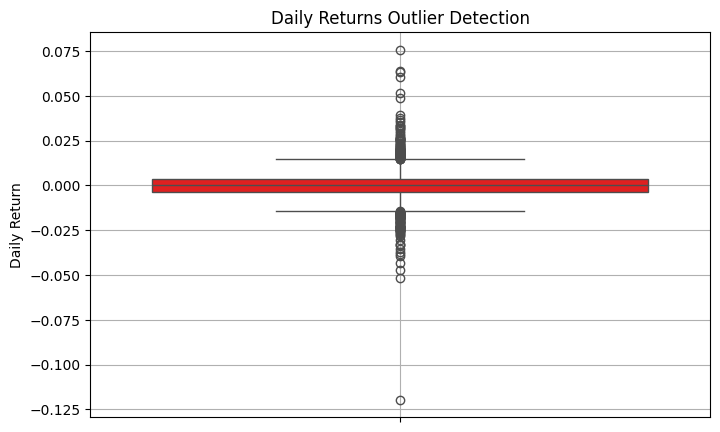

In [15]:
# --- 12. Outlier Detection (Boxplot) ---
plt.figure(figsize=(8,5))
sns.boxplot(y=df['Daily_Return'], color='red')
plt.title('Daily Returns Outlier Detection')
plt.ylabel('Daily Return')
plt.grid()
plt.show()

In [16]:
# --- 13. Key Metrics ---
mean_daily_return = df['Daily_Return'].mean()
std_daily_return = df['Daily_Return'].std()
annual_volatility = std_daily_return * np.sqrt(252)

print(f"Mean Daily Return: {mean_daily_return:.4f}")
print(f"Standard Deviation of Daily Returns: {std_daily_return:.4f}")
print(f"Annualized Volatility: {annual_volatility:.4f}")

Mean Daily Return: 0.0004
Standard Deviation of Daily Returns: 0.0090
Annualized Volatility: 0.1432


NameError: name 'model' is not defined